# 02 — Domain-Stratified Ensemble and Meta-Learner (Primary Analysis)

**Purpose:** This is the primary analysis notebook for the accompanying
manuscript. It builds a domain-stratified LightGBM ensemble (patient /
surgery / anesthetic domains, combined via a standardized logistic
meta-learner) and compares it against a monolithic LightGBM trained on the
same predictors, testing whether this architecture — previously validated
for perioperative outcome prediction on electronic health record data —
transfers to 30-day mortality prediction without losing discrimination or
calibration.

**What this notebook produces, in order:** cohort loading and
deduplication audit, duration-normalized hemodynamic burden variable
construction, feature engineering, domain definitions, temporal split,
domain-specific LightGBM models with patient-level out-of-fold prediction,
a hemodynamic-burden ablation with bootstrapped confidence interval, the
standardized meta-learner, the monolithic comparator model, head-to-head
and paired-bootstrap comparison between architectures, calibration curves,
SHAP interpretability by domain, vulnerability-stratified hemodynamic
risk-surface heatmaps, and subgroup/fairness analysis by ASA class, sex,
age, and procedure type.

**Produces:** Tables 1-4 and the first three rows of Table 5 in the
manuscript. Table 5's fourth row (the monolithic comparator's earlier,
different-feature-set counterpart) comes from the companion notebook,
`01_single_architecture_comparator.ipynb`, not from here.

**Requires:** a local `Standardized_data_all_4_20_26.xlsx` (not included;
governed by an institutional data use agreement).

**Temporal split:** Train ≤2018 | Validation 2019 | Test 2020 (held out
for all reported performance).


## Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              brier_score_loss)
from sklearn.calibration import calibration_curve
from statsmodels.stats.proportion import proportion_confint

Path('artifacts_domain').mkdir(exist_ok=True)

TARGET  = 'mort_30'
ID_COLS = ['study_id','study_enc_id','study_case_id']
DURATION_COL = 'proc_minutes'

print('Imports ready.')


Imports ready.


## Step 1 — Load Data
Loads the source file, deduplicates on patient/encounter/case ID, verifies duplicate groups agree on outcome.

In [2]:
XLSX_PATH = 'Standardized_data_all_4_20_26.xlsx'
PARQUET_CACHE = 'artifacts_domain/standardized_data_cache.parquet'

if Path(PARQUET_CACHE).exists():
    print('Loading from parquet cache...')
    df = pd.read_parquet(PARQUET_CACHE)
else:
    print('No cache found. Loading from Excel (this may take a few minutes)...')
    try:
        df = pd.read_excel(XLSX_PATH, engine='calamine')
        print('Loaded via python-calamine.')
    except Exception as e:
        print(f'calamine unavailable ({e}); falling back to openpyxl (slower)...')
        df = pd.read_excel(XLSX_PATH, engine='openpyxl')
        print('Loaded via openpyxl.')
    df.to_parquet(PARQUET_CACHE, index=False)
    print(f'Cached to {PARQUET_CACHE} for fast reload next time.')

print(f'\nLoaded (PRE-deduplication): {df.shape}')

# Fix mort_30 encoding (Yes/No strings in this file, unlike df_model_1.csv's 0/1)
if df[TARGET].dtype == object:
    df[TARGET] = df[TARGET].astype(str).str.strip().str.upper().map({'YES':1,'NO':0})

# Deduplication audit -- same logic and same result as the companion single-architecture model notebook
dup_mask = df.duplicated(subset=ID_COLS, keep=False)
dups = df[dup_mask].copy()
other_cols = [c for c in dups.columns if c not in ID_COLS]
nuniq = dups.groupby(ID_COLS)[other_cols].nunique()
cols_that_differ = list(nuniq.columns[(nuniq > 1).any(axis=0)])
grp_mort = dups.groupby(ID_COLS)[TARGET].agg(['nunique','sum'])
n_conflicting = int((grp_mort['nunique'] > 1).sum())
print(f'\nDeduplication audit: {len(grp_mort)} duplicate groups ({dup_mask.sum()} rows).')
print(f'  Columns that differ between copies: {cols_that_differ}')
print(f'  Groups where {TARGET} disagrees: {n_conflicting} (should be 0)')
if n_conflicting > 0:
    raise RuntimeError(f'{n_conflicting} duplicate group(s) disagree on {TARGET} -- investigate before proceeding.')

df = df.drop_duplicates(subset=ID_COLS, keep='first').copy()
print(f'\nLoaded (post-deduplication): {df.shape} | Deaths: {int(df[TARGET].sum()):,} | {100*df[TARGET].mean():.2f}%')

df[DURATION_COL] = pd.to_numeric(df[DURATION_COL], errors='coerce')
df['true_year'] = pd.to_numeric(df['true_year'], errors='coerce')
print(f'Years: {sorted(df["true_year"].dropna().unique().astype(int))}')


Loading from parquet cache...

Loaded (PRE-deduplication): (388407, 140)

Deduplication audit: 522 duplicate groups (1044 rows).
  Columns that differ between copies: []
  Groups where mort_30 disagrees: 0 (should be 0)

Loaded (post-deduplication): (387885, 140) | Deaths: 5,272 | 1.36%
Years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]


## Step 2 — Hemodynamic Burden Variables
Constructs duration-normalized MAP burden measures (time and area under/over threshold), standardized on training-set parameters.

In [3]:
required_hemo = ['perc_65','auc_stand65','auc_gtstand95','auc_gtstand150']
missing_hemo = [c for c in required_hemo if c not in df.columns]
if missing_hemo:
    raise KeyError(f'Missing hemodynamic source columns: {missing_hemo}')

for c in required_hemo:
    df[c] = pd.to_numeric(df[c], errors='coerce')

if df[DURATION_COL].isna().any() or (df[DURATION_COL] <= 0).any():
    raise ValueError(f'{DURATION_COL} contains missing or non-positive values.')

df['dn_AUT_65']     = df['auc_stand65'] / df[DURATION_COL]
df['dn_AAT_95_150'] = (df['auc_gtstand95'] - df['auc_gtstand150']) / df[DURATION_COL]

train_mask_full = df['true_year'] <= 2018

hemo_scaling_rows = []
for raw_var, z_var in [('dn_AUT_65','z_dn_AUT_65'), ('dn_AAT_95_150','z_dn_AAT_95_150')]:
    mu = df.loc[train_mask_full, raw_var].mean()
    sd = df.loc[train_mask_full, raw_var].std(ddof=1)
    if not np.isfinite(mu) or not np.isfinite(sd) or sd <= 0:
        raise ValueError(f'Invalid training statistics for {raw_var}: mean={mu}, SD={sd}')
    df[z_var] = (df[raw_var] - mu) / sd
    hemo_scaling_rows.append({'Variable':raw_var,'Standardized':z_var,'Train mean':mu,'Train SD':sd})

_put65_mu = df.loc[train_mask_full, 'perc_65'].mean()
_put65_sd = df.loc[train_mask_full, 'perc_65'].std(ddof=1)
df['z_PUT_65'] = (df['perc_65'] - _put65_mu) / _put65_sd
hemo_scaling_rows.append({'Variable':'perc_65','Standardized':'z_PUT_65','Train mean':_put65_mu,'Train SD':_put65_sd})

hemo_scaling_table = pd.DataFrame(hemo_scaling_rows)
hemo_scaling_table.to_csv('artifacts_domain/Hemodynamic_Scaling_Parameters.csv', index=False)
print('Hemodynamic burden variables constructed (train-only standardization):')
display(hemo_scaling_table.round(6))

HEMO_VARS = ['z_PUT_65', 'z_dn_AUT_65', 'z_dn_AAT_95_150']

# Direction check: died vs. survived medians for each burden variable.
# z_dn_AAT_95_150 is an effect-modifier (interacts with baseline vulnerability),
# so a flat marginal difference here is expected, not a bug.
for v in HEMO_VARS:
    died = df.loc[(train_mask_full) & (df[TARGET]==1), v]
    survived = df.loc[(train_mask_full) & (df[TARGET]==0), v]
    print(f'  {v}: died median={died.median():.4f} | survived median={survived.median():.4f}')


Hemodynamic burden variables constructed (train-only standardization):


,Variable,Standardized,Train mean,Train SD
0,dn_AUT_65,z_dn_AUT_65,0.022356,0.054915
1,dn_AAT_95_150,z_dn_AAT_95_150,0.029466,0.086351
2,perc_65,z_PUT_65,17.624366,25.612471


  z_PUT_65: died median=-0.2977 | survived median=-0.5227
  z_dn_AUT_65: died median=-0.3270 | survived median=-0.3872
  z_dn_AAT_95_150: died median=-0.3389 | survived median=-0.3372


## Step 3 — Feature Engineering
Builds derived predictors (drug-class counts, comorbidity counts, age groups, emergency-status flag) from raw fields.

In [4]:
vasopressor_cols = ['dobutamine','dopamine','ephedrine','epinephrine',
                    'milrinone','norepinephrine','phenylephrine','vasopressin']
antihtn_cols     = ['enalapril','esmolol','hydralazine','labetalol',
                    'metoprolol','propranolol','nicardipine','nitroprusside']
opioid_cols      = ['alfentanil','fentanyl','hydromorphone','meperidine',
                    'methadone','morphine','remifentanil','sufentanil']
nmba_cols        = ['atracurium','cisatracurium','mivacurium','pancuronium',
                    'rocuronium','succinylcholine','vecuronium']
sedative_cols    = ['diazepam','etomidate','ketamine','lorazepam','methohexital',
                    'midazolam','propofol','thiopental','dexmedetomidine']
comorb_cols      = ['anemia','ihd','ckd','copd','cancer','cancer_mets','arrhyth','cvd',
                    'chr_dialysis','chr_etoh','HF','dementia','DM','aorta','drug_abuse',
                    'HVD','hemi_para','HTN','liver_dz','obesity','PVD','psych','pul_vasc',
                    'resp_fail','transplant']
all_drug_cols    = vasopressor_cols + antihtn_cols + opioid_cols + nmba_cols + sedative_cols

# Comorbidity/drug/vasopressor/anti_htn columns are Yes/No strings in this file; map to 0/1.
yn_map = {'YES':1,'Y':1,'TRUE':1,'1':1,'NO':0,'N':0,'FALSE':0,'0':0}
for c in all_drug_cols + ['blood_admin', 'vasopressor', 'anti_htn'] + comorb_cols:
    df[c] = df[c].astype(str).str.strip().str.upper().map(yn_map).fillna(0).astype(int)
for c in ['albumin','heta_hydro']:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype(int)

# Encoding verification against known reference counts.
_check_vars = {'anemia': 124, 'dobutamine': 152, 'cancer': 1473}
print('Encoding verification (post-dedup cohort):')
for v, expected_approx in _check_vars.items():
    actual = int(df[v].sum())
    flag = 'OK' if actual > 0 else 'ZERO -- CHECK ENCODING'
    print(f'  {v}: N={actual} (expected ~{expected_approx})  [{flag}]')

df['n_vasopressors']         = df[vasopressor_cols].sum(axis=1)
df['any_vasopressor']        = (df['n_vasopressors'] >= 1).astype(int)
df['n_antihypertensives']    = df[antihtn_cols].sum(axis=1)
df['n_opioids']              = df[opioid_cols].sum(axis=1)
df['n_nmba']                 = df[nmba_cols].sum(axis=1)
df['n_sedatives']            = df[sedative_cols].sum(axis=1)
df['n_total_drugs']          = df[all_drug_cols].sum(axis=1)
df['n_comorbidities']        = df[comorb_cols].sum(axis=1)
df['high_risk_comorbidity']  = (df[['HF','ckd','liver_dz','cancer','resp_fail',
                                    'chr_dialysis','dementia']].sum(axis=1)>=1).astype(int)
df['any_colloid']            = ((df['albumin']==1)|(df['heta_hydro']==1)).astype(int)
df['resuscitation_intensity']= df['blood_admin'] + df['any_colloid'] + df['any_vasopressor']
df['age_proc']                = pd.to_numeric(df['age_proc'], errors='coerce')
df['age_group']              = pd.cut(df['age_proc'],bins=[0,50,65,75,85,200],
                                      labels=['lt50','50_64','65_74','75_84','gte85'],
                                      right=False).astype(str)
df['prolonged_surgery']      = (df[DURATION_COL] > 240).astype(int)
df['race_cat']                = df['race_eth'].fillna('Unknown').astype(str)
df['charlson_score']          = pd.to_numeric(df['charlson_score'], errors='coerce')
df['charlson_score']          = df['charlson_score'].fillna(df.loc[train_mask_full,'charlson_score'].median())
df['total_mac_hrs']           = pd.to_numeric(df['total_mac_hrs'], errors='coerce')

# Emergency status, derived from ASA-class E-suffix codes.
df['emergency_status'] = df['asa_class'].astype(str).str.endswith('E').astype(int)
print('Emergency status derived from asa_class:')
print(f"  Emergency: N={int(df['emergency_status'].sum()):,}, mortality={100*df.loc[df['emergency_status']==1,TARGET].mean():.2f}%")
print(f"  Non-emergency: N={int((1-df['emergency_status']).sum()):,}, mortality={100*df.loc[df['emergency_status']==0,TARGET].mean():.2f}%")

# Cross-check file-provided vasopressor/anti_htn flags against derived drug-count aggregates.
_agree_vaso = int((df['vasopressor'] == df['any_vasopressor']).mean() * 100)
_agree_htn  = int((df['anti_htn'] == (df['n_antihypertensives']>=1).astype(int)).mean() * 100)
print(f"\nFile-provided 'vasopressor' flag vs. derived any_vasopressor: {_agree_vaso}% agreement")
print(f"File-provided 'anti_htn' flag vs. derived any-antihypertensive: {_agree_htn}% agreement")

print('\nFeature engineering complete.')


Encoding verification (post-dedup cohort):
  anemia: N=124 (expected ~124)  [OK]
  dobutamine: N=151 (expected ~152)  [OK]
  cancer: N=1463 (expected ~1473)  [OK]
Emergency status derived from asa_class:
  Emergency: N=21,232, mortality=7.25%
  Non-emergency: N=366,653, mortality=1.02%

File-provided 'vasopressor' flag vs. derived any_vasopressor: 88% agreement
File-provided 'anti_htn' flag vs. derived any-antihypertensive: 100% agreement

Feature engineering complete.


## Step 4 — Domain Definitions
Groups predictors into patient-related, surgery-related, and anesthetic-related domains.

In [5]:
PATIENT_NUM = ['age_proc','charlson_score','n_comorbidities','high_risk_comorbidity'] + comorb_cols
PATIENT_CAT = ['SEX','race_cat','asa_class','age_group']

SURGERY_NUM = [DURATION_COL, 'emergency_status', 'prolonged_surgery']
SURGERY_CAT = ['proc_type']

ANESTH_NUM = ['total_mac_hrs','n_vasopressors','n_antihypertensives','n_nmba','n_opioids',
              'n_sedatives','n_total_drugs','resuscitation_intensity',
              'vasopressor','anti_htn'] + all_drug_cols + HEMO_VARS
ANESTH_CAT = []

DOMAINS = {
    'patient':    {'num': PATIENT_NUM, 'cat': PATIENT_CAT},
    'surgery':    {'num': SURGERY_NUM, 'cat': SURGERY_CAT},
    'anesthetic': {'num': ANESTH_NUM,  'cat': ANESTH_CAT},
}

for name, d in DOMAINS.items():
    print(f'{name}: {len(d["num"])} numeric + {len(d["cat"])} categorical = {len(d["num"])+len(d["cat"])} variables')
print(f'\nHemodynamic burden vars in anesthetic domain: {HEMO_VARS}')
print('NOTE: chronic-medication categories (antispasmodics, GI agents, steroids, antibiotics)')
print('and spinal/epidural anesthesia flag are not captured in this EHR extract -- absent from')
print('the patient/anesthetic domains here versus the delirium model\'s published variable list.')


patient: 29 numeric + 4 categorical = 33 variables
surgery: 3 numeric + 1 categorical = 4 variables
anesthetic: 53 numeric + 0 categorical = 53 variables

Hemodynamic burden vars in anesthetic domain: ['z_PUT_65', 'z_dn_AUT_65', 'z_dn_AAT_95_150']
NOTE: chronic-medication categories (antispasmodics, GI agents, steroids, antibiotics)
and spinal/epidural anesthesia flag are not captured in this EHR extract -- absent from
the patient/anesthetic domains here versus the delirium model's published variable list.


## Step 5 — Temporal Split
Train ≤2018 / Validation 2019 / Test 2020.

In [6]:
train_df = df[df['true_year'] <= 2018].copy()
val_df   = df[df['true_year'] == 2019].copy()
test_df  = df[df['true_year'] == 2020].copy()

for name, part in [('Train <=2018',train_df),('Val  2019',val_df),('Test 2020',test_df)]:
    print(f'{name}: N={len(part):>7,} | Deaths={int(part[TARGET].sum()):>5} | {100*part[TARGET].mean():.3f}%')

y_train = train_df[TARGET].astype(int).values
y_val   = val_df[TARGET].astype(int).values
y_test  = test_df[TARGET].astype(int).values
groups_train = train_df['study_id'].values  # patient-level grouping for GroupKFold

scale_pos_weight = (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
print(f'\nscale_pos_weight: {scale_pos_weight:.2f}')

_ids_train, _ids_val, _ids_test = set(train_df['study_id']), set(val_df['study_id']), set(test_df['study_id'])
print('No train/test overlap:', len(_ids_train & _ids_test) == 0)
print('No train/val overlap: ', len(_ids_train & _ids_val)  == 0)
print('No val/test overlap:  ', len(_ids_val & _ids_test)   == 0)


Train <=2018: N=278,514 | Deaths= 4105 | 1.474%
Val  2019: N= 52,117 | Deaths=  497 | 0.954%
Test 2020: N= 57,254 | Deaths=  670 | 1.170%

scale_pos_weight: 66.85
No train/test overlap: True
No train/val overlap:  True
No val/test overlap:   True


## Step 6 — Domain Preprocessing
Label-encodes categorical variables per domain, fit on training data only.

In [7]:
def prep_domain_matrix(train_df, val_df, test_df, num_cols, cat_cols):
    le_dict = {}
    Xtr = train_df[num_cols].astype(float).copy()
    Xv  = val_df[num_cols].astype(float).copy()
    Xte = test_df[num_cols].astype(float).copy()
    for c in cat_cols:
        le = LabelEncoder()
        train_vals = train_df[c].astype(str)
        le.fit(train_vals)  # train-only, per the markdown claim above
        train_classes = set(le.classes_)
        unseen_code = len(le.classes_)  # reserved code for categories not seen in training

        def _safe_transform(series, _le=le, _known=train_classes, _unseen=unseen_code):
            s = series.astype(str)
            known_mask = s.isin(_known)
            out = np.full(len(s), _unseen, dtype=int)
            out[known_mask.values] = _le.transform(s[known_mask])
            n_unseen = int((~known_mask).sum())
            return out, n_unseen

        Xtr[c+'_enc'] = le.transform(train_vals)
        Xv[c+'_enc'], n_unseen_val  = _safe_transform(val_df[c])
        Xte[c+'_enc'], n_unseen_test = _safe_transform(test_df[c])
        if n_unseen_val or n_unseen_test:
            print(f"  {c}: {n_unseen_val} unseen-category rows in val, {n_unseen_test} in test "
                  f"(mapped to reserved code {unseen_code}, not dropped)")
        le_dict[c] = le
    cat_indices = [Xtr.columns.get_loc(c+'_enc') for c in cat_cols]
    return Xtr, Xv, Xte, cat_indices, le_dict

domain_matrices = {}
for name, d in DOMAINS.items():
    Xtr, Xv, Xte, cat_idx, le_dict = prep_domain_matrix(train_df, val_df, test_df, d['num'], d['cat'])
    domain_matrices[name] = {'Xtr':Xtr, 'Xv':Xv, 'Xte':Xte, 'cat_idx':cat_idx}
    print(f'{name}: train shape {Xtr.shape}, categorical indices {cat_idx}')


patient: train shape (278514, 33), categorical indices [29, 30, 31, 32]
surgery: train shape (278514, 4), categorical indices [3]
anesthetic: train shape (278514, 53), categorical indices []


## Step 7 — Domain-Specific LightGBM Models
Trains one LightGBM per domain with patient-level 5-fold out-of-fold predictions for the meta-learner, then refits each on the full training set.

In [8]:
LGB_PARAMS = {
    'objective':'binary', 'metric':'average_precision', 'boosting_type':'gbdt',
    'learning_rate':0.03, 'num_leaves':63, 'max_depth':-1,
    'min_child_samples':100, 'subsample':0.8, 'colsample_bytree':0.8,
    'reg_lambda':1.0, 'scale_pos_weight':scale_pos_weight,
    'random_state':42, 'n_jobs':-1, 'verbose':-1
}

def fit_domain_oof(name, Xtr, y_train, groups_train, cat_idx, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    oof = np.zeros(len(y_train))
    for fold, (tr_idx, val_idx) in enumerate(gkf.split(Xtr, y_train, groups=groups_train)):
        lgb_tr = lgb.Dataset(Xtr.iloc[tr_idx], label=y_train[tr_idx],
                              categorical_feature=cat_idx, free_raw_data=False)
        lgb_va = lgb.Dataset(Xtr.iloc[val_idx], label=y_train[val_idx],
                              categorical_feature=cat_idx, free_raw_data=False)
        model = lgb.train(LGB_PARAMS, lgb_tr, num_boost_round=2000,
                          valid_sets=[lgb_va],
                          callbacks=[lgb.early_stopping(50, verbose=False)])
        oof[val_idx] = model.predict(Xtr.iloc[val_idx])
        print(f'  {name} fold {fold+1}/{n_splits}: best_iter={model.best_iteration}, '
              f'fold AUROC={roc_auc_score(y_train[val_idx], oof[val_idx]):.4f}')
    return oof

def fit_domain_full(name, Xtr, y_train, cat_idx, Xv, y_val):
    lgb_tr = lgb.Dataset(Xtr, label=y_train, categorical_feature=cat_idx, free_raw_data=False)
    lgb_va = lgb.Dataset(Xv, label=y_val, categorical_feature=cat_idx, free_raw_data=False)
    model = lgb.train(LGB_PARAMS, lgb_tr, num_boost_round=2000,
                      valid_sets=[lgb_va],
                      callbacks=[lgb.early_stopping(100, verbose=True)])
    return model

def paired_bootstrap_difference(y, p_a, p_b, id_values, metric_fn, n_boot=2000, seed=42, alpha=0.05):
    """CI on (metric(p_a) - metric(p_b)) using the SAME patient-level resample
    for both models on each iteration -- this is what makes it 'paired'. Defined
    here (rather than only at Step 10) so Step 7b's ablation can also use it."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y); p_a = np.asarray(p_a); p_b = np.asarray(p_b); ids = np.asarray(id_values)
    id_to_idx = {}
    for i, uid in enumerate(ids):
        id_to_idx.setdefault(uid, []).append(i)
    uniq_ids = np.array(list(id_to_idx.keys()))
    diffs = []
    for _ in range(n_boot):
        samp_ids = rng.choice(uniq_ids, size=len(uniq_ids), replace=True)
        idx = np.concatenate([id_to_idx[i] for i in samp_ids])
        yb = y[idx]
        if len(np.unique(yb)) < 2:
            continue
        diffs.append(metric_fn(yb, p_a[idx]) - metric_fn(yb, p_b[idx]))
    diffs = np.array(diffs)
    point_diff = metric_fn(y, p_a) - metric_fn(y, p_b)
    ci_lo, ci_hi = np.percentile(diffs, 100*alpha/2), np.percentile(diffs, 100*(1-alpha/2))
    p_value_twosided = 2 * min((diffs > 0).mean(), (diffs < 0).mean())
    return {'Point difference': point_diff, 'CI low': ci_lo, 'CI high': ci_hi,
            'Includes zero': bool(ci_lo <= 0 <= ci_hi), 'Approx two-sided p': p_value_twosided,
            'N bootstrap resamples used': len(diffs)}

domain_oof = {}
domain_models_full = {}
domain_oof_auroc = {}

for name, mats in domain_matrices.items():
    print(f'\n=== Domain: {name} ===')
    oof = fit_domain_oof(name, mats['Xtr'], y_train, groups_train, mats['cat_idx'])
    domain_oof[name] = oof
    domain_oof_auroc[name] = roc_auc_score(y_train, oof)
    print(f'  {name} OOF AUROC (train): {domain_oof_auroc[name]:.4f}')
    print(f'  Refitting {name} on full training set for val/test inference...')
    domain_models_full[name] = fit_domain_full(name, mats['Xtr'], y_train, mats['cat_idx'],
                                                mats['Xv'], y_val)

domain_oof_table = pd.DataFrame([{'Domain':k, 'N variables': len(DOMAINS[k]['num'])+len(DOMAINS[k]['cat']),
                                   'OOF AUROC (train)': v} for k,v in domain_oof_auroc.items()])
domain_oof_table.to_csv('artifacts_domain/Domain_OOF_AUROC.csv', index=False)
print('\n-- Domain-only discriminative power (OOF, train) --')
display(domain_oof_table.round(4))



=== Domain: patient ===
  patient fold 1/5: best_iter=281, fold AUROC=0.9046
  patient fold 2/5: best_iter=95, fold AUROC=0.9044
  patient fold 3/5: best_iter=87, fold AUROC=0.9039
  patient fold 4/5: best_iter=189, fold AUROC=0.8996
  patient fold 5/5: best_iter=185, fold AUROC=0.9057
  patient OOF AUROC (train): 0.9027
  Refitting patient on full training set for val/test inference...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[179]	valid_0's average_precision: 0.198807

=== Domain: surgery ===
  surgery fold 1/5: best_iter=137, fold AUROC=0.7648
  surgery fold 2/5: best_iter=349, fold AUROC=0.7435
  surgery fold 3/5: best_iter=152, fold AUROC=0.7664
  surgery fold 4/5: best_iter=69, fold AUROC=0.7540
  surgery fold 5/5: best_iter=207, fold AUROC=0.7610
  surgery OOF AUROC (train): 0.7573
  Refitting surgery on full training set for val/test inference...
Training until validation scores don't improve for 100 rounds
Early stopping

,Domain,N variables,OOF AUROC (train)
0,patient,33,0.9027
1,surgery,4,0.7573
2,anesthetic,53,0.8179


## Step 7b — Hemodynamic Burden Ablation
Compares anesthetic-domain discrimination with and without the hemodynamic burden variables, using a bootstrap confidence interval on the difference.

In [9]:
anesth_no_hemo_num = [c for c in ANESTH_NUM if c not in HEMO_VARS]
Xtr_anes_no_hemo, _, _, anes_cat_idx_no_hemo, _ = prep_domain_matrix(
    train_df, val_df, test_df, anesth_no_hemo_num, ANESTH_CAT)

oof_anes_no_hemo = fit_domain_oof('anesthetic (no hemo)', Xtr_anes_no_hemo, y_train, groups_train, anes_cat_idx_no_hemo)
auroc_no_hemo = roc_auc_score(y_train, oof_anes_no_hemo)

ablation_table = pd.DataFrame([
    {'Configuration': 'Anesthetic domain, WITHOUT hemodynamic burden', 'N variables': len(anesth_no_hemo_num), 'OOF AUROC (train)': auroc_no_hemo},
    {'Configuration': 'Anesthetic domain, WITH hemodynamic burden',    'N variables': len(ANESTH_NUM),         'OOF AUROC (train)': domain_oof_auroc['anesthetic']},
])
ablation_table.to_csv('artifacts_domain/Anesthetic_Hemodynamic_Ablation.csv', index=False)
print('Anesthetic domain ablation:')
display(ablation_table.round(4))

delta = domain_oof_auroc['anesthetic'] - auroc_no_hemo
print(f'\nDelta (with hemo - without hemo): {delta:+.4f}')

# Bootstrap CI on the ablation delta (patient-level, same folds both configurations).
ablation_ci = paired_bootstrap_difference(y_train, domain_oof['anesthetic'], oof_anes_no_hemo,
                                           groups_train, roc_auc_score)
ablation_ci_table = pd.DataFrame([{'Comparison':'Anesthetic AUROC, with hemo - without hemo', **ablation_ci}])
ablation_ci_table.to_csv('artifacts_domain/Ablation_Bootstrap_CI.csv', index=False)
print('\nBootstrap CI on the ablation delta (patient-level, train set):')
display(ablation_ci_table.round(4))

if ablation_ci['Includes zero']:
    print('\nCI includes zero: no statistically distinguishable effect.')
else:
    print('\nCI does not include zero: statistically distinguishable effect.')
    print(f'Direction: {"hemodynamic burden helps" if ablation_ci["Point difference"]>0 else "hemodynamic burden hurts"} the anesthetic domain.')


  anesthetic (no hemo) fold 1/5: best_iter=241, fold AUROC=0.8103
  anesthetic (no hemo) fold 2/5: best_iter=256, fold AUROC=0.8094
  anesthetic (no hemo) fold 3/5: best_iter=202, fold AUROC=0.8121
  anesthetic (no hemo) fold 4/5: best_iter=254, fold AUROC=0.8109
  anesthetic (no hemo) fold 5/5: best_iter=264, fold AUROC=0.8326
Anesthetic domain ablation:


,Configuration,N variables,OOF AUROC (train)
0,"Anesthetic domain, WITHOUT hemodynamic burden",50,0.8148
1,"Anesthetic domain, WITH hemodynamic burden",53,0.8179



Delta (with hemo - without hemo): +0.0031

Bootstrap CI on the ablation delta (patient-level, train set):


,Comparison,Point difference,CI low,CI high,Includes zero,Approx two-sided p,N bootstrap resamples used
0,"Anesthetic AUROC, with hemo - without hemo",0.0031,0.0001,0.0062,False,0.043,2000



CI does not include zero: statistically distinguishable effect.
Direction: hemodynamic burden helps the anesthetic domain.


## Step 8 — Meta-Learner
Combines standardized, logit-transformed domain probabilities via an L2-penalized logistic regression.

In [10]:
def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1-eps)
    return np.log(p / (1-p))

_logit_train = {name: _logit(domain_oof[name]) for name in DOMAINS}
_logit_val   = {name: _logit(domain_models_full[name].predict(domain_matrices[name]['Xv']))  for name in DOMAINS}
_logit_test  = {name: _logit(domain_models_full[name].predict(domain_matrices[name]['Xte'])) for name in DOMAINS}

# standardize on TRAIN only, applied unchanged to val/test -- leak-safe,
# matching every other standardization step in this project
_meta_scalers = {}
for name in DOMAINS:
    mu, sd = _logit_train[name].mean(), _logit_train[name].std(ddof=1)
    _meta_scalers[name] = (mu, sd)
    _logit_train[name] = (_logit_train[name] - mu) / sd
    _logit_val[name]   = (_logit_val[name]   - mu) / sd
    _logit_test[name]  = (_logit_test[name]  - mu) / sd

meta_X_train = np.column_stack([_logit_train[name] for name in DOMAINS])
meta_X_val   = np.column_stack([_logit_val[name]   for name in DOMAINS])
meta_X_test  = np.column_stack([_logit_test[name]  for name in DOMAINS])

meta_learner = LogisticRegression(penalty='l2', C=1.0, max_iter=2000, random_state=42)
meta_learner.fit(meta_X_train, y_train)

p_stacked_val  = meta_learner.predict_proba(meta_X_val)[:,1]
p_stacked_test = meta_learner.predict_proba(meta_X_test)[:,1]

meta_coef_table = pd.DataFrame({'Domain': list(DOMAINS.keys()),
                                 'Meta-learner coefficient (per 1 SD, logit scale)': meta_learner.coef_[0]})
meta_coef_table.to_csv('artifacts_domain/MetaLearner_Coefficients.csv', index=False)
print('Meta-learner coefficients on standardized logit-transformed domain inputs')
print('(comparable per-SD basis -- still suggestive, not a calibrated importance ranking):')
display(meta_coef_table.round(4))

print(f'\nStacked ensemble -- Val AUROC:  {roc_auc_score(y_val, p_stacked_val):.4f}')
print(f'Stacked ensemble -- Test AUROC: {roc_auc_score(y_test, p_stacked_test):.4f}')
print(f'Stacked ensemble -- Test PR-AUC: {average_precision_score(y_test, p_stacked_test):.4f}')


Meta-learner coefficients on standardized logit-transformed domain inputs
(comparable per-SD basis -- still suggestive, not a calibrated importance ranking):


,Domain,"Meta-learner coefficient (per 1 SD, logit scale)"
0,patient,1.6958
1,surgery,0.2985
2,anesthetic,0.5872



Stacked ensemble -- Val AUROC:  0.9304
Stacked ensemble -- Test AUROC: 0.9194
Stacked ensemble -- Test PR-AUC: 0.2617


## Step 9 — Single Full-Feature Model
Trains one LightGBM on the union of all domain predictors, as the comparator architecture. Both this and the domain-stacked model are Platt-calibrated on validation before any Brier/calibration comparison.

In [11]:
SINGLE_NUM = PATIENT_NUM + SURGERY_NUM + ANESTH_NUM
SINGLE_CAT = PATIENT_CAT + SURGERY_CAT + ANESTH_CAT
SINGLE_CAT = list(dict.fromkeys(SINGLE_CAT))  # dedupe while preserving order

Xtr_single, Xv_single, Xte_single, cat_idx_single, _ = prep_domain_matrix(
    train_df, val_df, test_df, SINGLE_NUM, SINGLE_CAT)

lgb_tr_single = lgb.Dataset(Xtr_single, label=y_train, categorical_feature=cat_idx_single, free_raw_data=False)
lgb_va_single = lgb.Dataset(Xv_single,  label=y_val,   categorical_feature=cat_idx_single, free_raw_data=False)
single_model = lgb.train(LGB_PARAMS, lgb_tr_single, num_boost_round=2000,
                         valid_sets=[lgb_va_single],
                         callbacks=[lgb.early_stopping(100, verbose=True)])

p_single_val_raw  = single_model.predict(Xv_single)
p_single_test_raw = single_model.predict(Xte_single)

def _logit_clip(p, eps=1e-7):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

platt_single = LogisticRegression(C=1e10, solver='lbfgs', max_iter=1000)
platt_single.fit(_logit_clip(p_single_val_raw).reshape(-1,1), y_val)
p_single_test = platt_single.predict_proba(_logit_clip(p_single_test_raw).reshape(-1,1))[:,1]

print(f'Single full-feature model, RAW      -- Test Brier: {brier_score_loss(y_test, p_single_test_raw):.4f}')
print(f'Single full-feature model, CALIBRATED -- Test Brier: {brier_score_loss(y_test, p_single_test):.4f}')
print(f'\nSingle full-feature model -- Test AUROC:  {roc_auc_score(y_test, p_single_test):.4f}  (identical raw vs. calibrated -- monotonic transform)')
print(f'Single full-feature model -- Test PR-AUC: {average_precision_score(y_test, p_single_test):.4f}  (identical raw vs. calibrated -- monotonic transform)')
print('\np_single_test now refers to the CALIBRATED version for all downstream Brier/calibration comparisons.')


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[239]	valid_0's average_precision: 0.271321
Single full-feature model, RAW      -- Test Brier: 0.0956
Single full-feature model, CALIBRATED -- Test Brier: 0.0098

Single full-feature model -- Test AUROC:  0.9228  (identical raw vs. calibrated -- monotonic transform)
Single full-feature model -- Test PR-AUC: 0.2695  (identical raw vs. calibrated -- monotonic transform)

p_single_test now refers to the CALIBRATED version for all downstream Brier/calibration comparisons.


## Step 10 — Head-to-Head Comparison
Bootstrap-CI comparison of the domain-stacked ensemble against the single full-feature model.

In [12]:
def bootstrap_performance(y, p, id_values, n_boot=1000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed)
    y = np.asarray(y); p = np.asarray(p); ids = np.asarray(id_values)
    id_to_idx = {}
    for i, uid in enumerate(ids):
        id_to_idx.setdefault(uid, []).append(i)
    uniq_ids = np.array(list(id_to_idx.keys()))
    aurocs, praucs, briers = [], [], []
    for _ in range(n_boot):
        samp_ids = rng.choice(uniq_ids, size=len(uniq_ids), replace=True)
        idx = np.concatenate([id_to_idx[i] for i in samp_ids])
        yb, pb = y[idx], p[idx]
        if len(np.unique(yb)) < 2:
            continue
        aurocs.append(roc_auc_score(yb, pb))
        praucs.append(average_precision_score(yb, pb))
        briers.append(brier_score_loss(yb, pb))
    def _ci(arr):
        arr = np.array(arr)
        return float(np.mean(arr)), float(np.percentile(arr, 100*alpha/2)), float(np.percentile(arr, 100*(1-alpha/2)))
    a = _ci(aurocs); p_ = _ci(praucs); b = _ci(briers)
    return {'AUROC boot mean':a[0],'AUROC CI low':a[1],'AUROC CI high':a[2],
            'PR-AUC boot mean':p_[0],'PR-AUC CI low':p_[1],'PR-AUC CI high':p_[2],
            'Brier boot mean':b[0],'Brier CI low':b[1],'Brier CI high':b[2]}

perf_stacked = bootstrap_performance(y_test, p_stacked_test, test_df['study_id'].values)
perf_single  = bootstrap_performance(y_test, p_single_test,  test_df['study_id'].values)

comparison_table = pd.DataFrame([
    {'Model':'Domain-stacked ensemble', **perf_stacked},
    {'Model':'Single full-feature model', **perf_single},
])
comparison_table.to_csv('artifacts_domain/Stacked_vs_Single_Comparison.csv', index=False)
print('Domain-stacked ensemble vs. single full-feature model (Test 2020, bootstrap 95% CI):')
display(comparison_table.round(4))

delta_auroc = perf_stacked['AUROC boot mean'] - perf_single['AUROC boot mean']
print(f'\nDelta AUROC (stacked - single): {delta_auroc:+.4f}')
if abs(delta_auroc) < 0.01:
    print('NOTE: performance is essentially tied. The story here should lean on the')
    print('sequential/dynamic-disclosure framing (patient -> surgery -> anesthetic risk')
    print('evolution) and domain-level interpretability, not a raw-AUROC improvement claim.')


Domain-stacked ensemble vs. single full-feature model (Test 2020, bootstrap 95% CI):


,Model,AUROC boot mean,AUROC CI low,AUROC CI high,PR-AUC boot mean,PR-AUC CI low,PR-AUC CI high,Brier boot mean,Brier CI low,Brier CI high
0,Domain-stacked ensemble,0.9194,0.9095,0.9282,0.2619,0.2280,0.2956,0.0100,0.0093,0.0106
1,Single full-feature model,0.9227,0.9133,0.9315,0.2696,0.2355,0.3040,0.0098,0.0092,0.0105



Delta AUROC (stacked - single): -0.0034
NOTE: performance is essentially tied. The story here should lean on the
sequential/dynamic-disclosure framing (patient -> surgery -> anesthetic risk
evolution) and domain-level interpretability, not a raw-AUROC improvement claim.


## Step 10b — Paired Bootstrap
Paired bootstrap test (same resample scores both models) on the AUROC and PR-AUC differences between architectures.

In [13]:
paired_auroc = paired_bootstrap_difference(y_test, p_stacked_test, p_single_test,
                                            test_df['study_id'].values, roc_auc_score)
paired_prauc = paired_bootstrap_difference(y_test, p_stacked_test, p_single_test,
                                            test_df['study_id'].values, average_precision_score)

paired_table = pd.DataFrame([
    {'Metric':'AUROC (stacked - single)', **paired_auroc},
    {'Metric':'PR-AUC (stacked - single)', **paired_prauc},
])
paired_table.to_csv('artifacts_domain/Paired_Bootstrap_Stacked_vs_Single.csv', index=False)
print('Paired bootstrap: domain-stacked ensemble vs. single full-feature model (same resample, Test 2020):')
display(paired_table.round(4))

print()
if paired_prauc['Includes zero']:
    print('PR-AUC difference CI includes zero: architectures are statistically indistinguishable.')
else:
    print('PR-AUC difference CI does not include zero: a statistically supported difference between architectures.')


Paired bootstrap: domain-stacked ensemble vs. single full-feature model (same resample, Test 2020):


,Metric,Point difference,CI low,CI high,Includes zero,Approx two-sided p,N bootstrap resamples used
0,AUROC (stacked - single),-0.0034,-0.0073,0.0009,True,0.109,2000
1,PR-AUC (stacked - single),-0.0079,-0.0198,0.0047,True,0.228,2000



PR-AUC difference CI includes zero: architectures are statistically indistinguishable.


## Step 11 — Calibration Curves

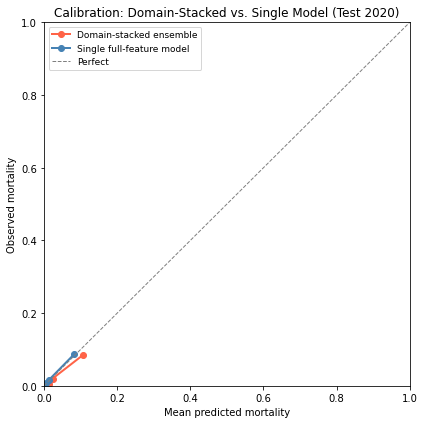

Saved -> artifacts_domain/calibration_comparison.png


In [14]:
fig, ax = plt.subplots(figsize=(6,6))
for label, p, color in [('Domain-stacked ensemble', p_stacked_test, 'tomato'),
                         ('Single full-feature model', p_single_test, 'steelblue')]:
    pt, pp = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    ax.plot(pp, pt, 'o-', color=color, linewidth=2, label=label)
ax_max = min(max(p_stacked_test.max(), p_single_test.max())*1.2, 1.0)
ax.plot([0,ax_max],[0,ax_max],'--',color='gray',linewidth=1,label='Perfect')
ax.set_xlim(0,ax_max); ax.set_ylim(0,ax_max)
ax.set_xlabel('Mean predicted mortality'); ax.set_ylabel('Observed mortality')
ax.set_title('Calibration: Domain-Stacked vs. Single Model (Test 2020)'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('artifacts_domain/calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> artifacts_domain/calibration_comparison.png')


## Step 12 — SHAP by Domain
SHAP feature importance for each domain model, plus explicit reporting of all three hemodynamic burden variables regardless of rank.

In [15]:
np.random.seed(42)
shap_idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)

domain_shap_top = {}
domain_shap_full = {}
for name, mats in domain_matrices.items():
    X_shap = mats['Xte'].iloc[shap_idx]
    explainer = shap.TreeExplainer(domain_models_full[name])
    shap_vals = explainer.shap_values(X_shap.values)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    mean_shap_full = pd.DataFrame({
        'Feature': X_shap.columns,
        'Mean |SHAP|': np.abs(shap_vals).mean(axis=0)
    }).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
    domain_shap_full[name] = mean_shap_full
    mean_shap = mean_shap_full.head(10)
    domain_shap_top[name] = mean_shap
    mean_shap.to_csv(f'artifacts_domain/SHAP_top10_{name}.csv', index=False)
    print(f'\nTop 10 features -- {name} domain:')
    display(mean_shap.round(6))

# Report all 3 hemodynamic burden variables explicitly, regardless of top-10 rank.
print('\nSHAP importance for all 3 hemodynamic burden variables (anesthetic domain, regardless of rank):')
_anesth_full = domain_shap_full['anesthetic'].reset_index().rename(columns={'index':'Rank'})
_anesth_full['Rank'] = _anesth_full['Rank'] + 1
_hemo_shap_rows = _anesth_full[_anesth_full['Feature'].isin(HEMO_VARS)]
display(_hemo_shap_rows)
_hemo_shap_rows.to_csv('artifacts_domain/SHAP_hemodynamic_vars_all3.csv', index=False)



Top 10 features -- patient domain:


,Feature,Mean |SHAP|
0,asa_class_enc,1.666492
1,age_proc,0.616197
2,charlson_score,0.364358
3,SEX_enc,0.202165
4,race_cat_enc,0.146193
5,age_group_enc,0.067458
6,n_comorbidities,0.007210
7,psych,0.002390
8,high_risk_comorbidity,0.001769
9,cancer,0.000641



Top 10 features -- surgery domain:


,Feature,Mean |SHAP|
0,proc_type_enc,0.654609
1,proc_minutes,0.161709
2,emergency_status,0.143858
3,prolonged_surgery,0.007353



Top 10 features -- anesthetic domain:


,Feature,Mean |SHAP|
0,resuscitation_intensity,0.446303
1,total_mac_hrs,0.442679
2,n_nmba,0.290574
3,midazolam,0.208421
4,ephedrine,0.184463
5,propofol,0.133768
6,n_sedatives,0.129203
7,n_opioids,0.126335
8,z_dn_AAT_95_150,0.115478
9,z_dn_AUT_65,0.097611



SHAP importance for all 3 hemodynamic burden variables (anesthetic domain, regardless of rank):


,Rank,Feature,Mean |SHAP|
8,9,z_dn_AAT_95_150,0.115478
9,10,z_dn_AUT_65,0.097611
10,11,z_PUT_65,0.094962


## Step 13 — Risk-Surface Heatmaps
Empirical mortality rate by vulnerability decile × hemodynamic exposure decile, for each of the three burden measures.


=== Risk surface: MAP<65 duration (PUT) (z_PUT_65) ===


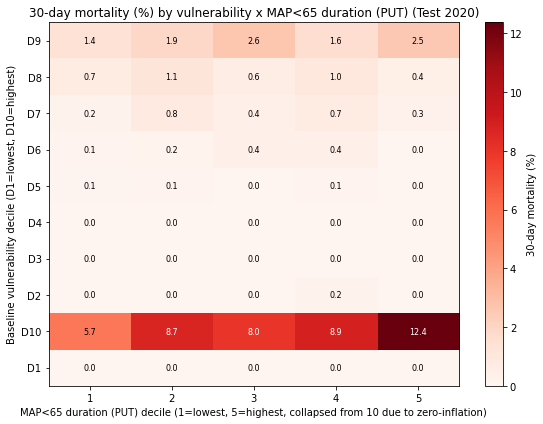

Saved -> artifacts_domain/RiskSurface_z_PUT_65.png  (5 distinct exposure bins)

=== Risk surface: AUT<65 burden (z_dn_AUT_65) ===


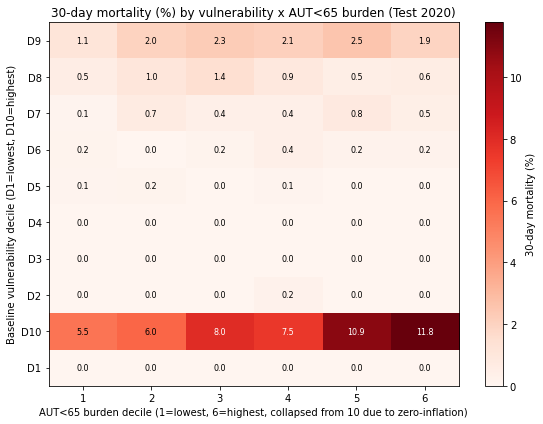

Saved -> artifacts_domain/RiskSurface_z_dn_AUT_65.png  (6 distinct exposure bins)

=== Risk surface: AAT 95-150 high-MAP burden (z_dn_AAT_95_150) ===


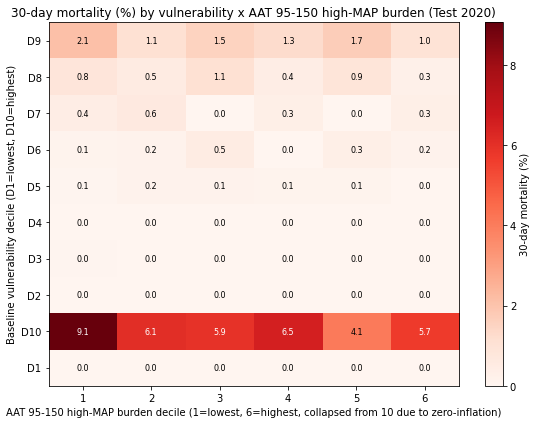

Saved -> artifacts_domain/RiskSurface_z_dn_AAT_95_150.png  (6 distinct exposure bins)

Risk surfaces constructed for all 3 hemodynamic exposures.


In [16]:
asa_map = {'1':1,'2':2,'3':3,'4':4,'5':5,'6':6,'1E':1,'2E':2,'3E':3,'4E':4,'5E':5,'6E':6}
def asa_numeric(d):
    return d['asa_class'].astype(str).map(asa_map).fillna(3).astype(float)

train_V = pd.DataFrame({'asa': asa_numeric(train_df), 'age': train_df['age_proc'].fillna(train_df['age_proc'].median()),
                         'cci': train_df['charlson_score'].fillna(0)})
test_V  = pd.DataFrame({'asa': asa_numeric(test_df), 'age': test_df['age_proc'].fillna(train_df['age_proc'].median()),
                         'cci': test_df['charlson_score'].fillna(0)})
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(train_V)
X_te_s = scaler.transform(test_V)
vuln_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
vuln_lr.fit(X_tr_s, y_train)
p_vuln_test = vuln_lr.predict_proba(X_te_s)[:,1]

vuln_edges = np.unique(np.quantile(vuln_lr.predict_proba(X_tr_s)[:,1], np.linspace(0,1,11)))
vuln_edges[0] = -np.inf; vuln_edges[-1] = np.inf
vuln_labels = [f'D{i}' for i in range(1, len(vuln_edges))]

def build_and_plot_risk_surface(exposure_col, exposure_label, min_n=20):
    work = test_df[[TARGET, exposure_col]].copy()
    work['vuln_decile'] = pd.cut(p_vuln_test, bins=vuln_edges, labels=vuln_labels, include_lowest=True)
    try:
        work['exposure_decile'] = pd.qcut(work[exposure_col], q=10, labels=False, duplicates='drop') + 1
    except ValueError as e:
        raise ValueError(f'Could not bin {exposure_col} into deciles: {e}')

    rows = []
    for (vd, ed), g in work.groupby(['vuln_decile','exposure_decile'], observed=True):
        n = len(g); events = int(g[TARGET].sum())
        suppressed = n < min_n
        rate = 100*events/n if n else np.nan
        rows.append({'Vulnerability decile':vd, 'Exposure decile':ed, 'N':n, 'Events':events,
                     'Mortality (%)': round(rate,3) if not suppressed else np.nan,
                     'Suppressed (N<%d)' % min_n: suppressed})
    cell_table = pd.DataFrame(rows)
    grid_df = cell_table.pivot(index='Vulnerability decile', columns='Exposure decile', values='Mortality (%)').sort_index()
    safe_name = exposure_col.replace('.','_')
    cell_table.to_csv(f'artifacts_domain/RiskSurface_{safe_name}_CellTable.csv', index=False)
    n_exposure_bins = grid_df.shape[1]

    fig, ax = plt.subplots(figsize=(8,6))
    data = grid_df.to_numpy(dtype=float)
    masked = np.ma.masked_invalid(data)
    cmap = plt.cm.Reds.copy(); cmap.set_bad(color='lightgray')
    im = ax.imshow(masked, cmap=cmap, aspect='auto', origin='lower')
    ax.set_xticks(range(grid_df.shape[1])); ax.set_xticklabels(grid_df.columns.astype(int))
    ax.set_yticks(range(grid_df.shape[0])); ax.set_yticklabels(grid_df.index.astype(str))
    ax.set_xlabel(f'{exposure_label} decile (1=lowest, {n_exposure_bins}=highest'
                  + (', collapsed from 10 due to zero-inflation)' if n_exposure_bins < 10 else ')'))
    ax.set_ylabel(f'Baseline vulnerability decile (D1=lowest, D{grid_df.shape[0]}=highest)')
    ax.set_title(f'30-day mortality (%) by vulnerability x {exposure_label} (Test 2020)')
    finite = data[np.isfinite(data)]
    thresh = 0.55*finite.max() if len(finite) else 0
    for i in range(grid_df.shape[0]):
        for j in range(grid_df.shape[1]):
            val = data[i,j]
            if np.isfinite(val):
                ax.text(j, i, f'{val:.1f}', ha='center', va='center', color='white' if val>thresh else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, label='30-day mortality (%)')
    fig.tight_layout()
    fig.savefig(f'artifacts_domain/RiskSurface_{safe_name}.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved -> artifacts_domain/RiskSurface_{safe_name}.png  ({n_exposure_bins} distinct exposure bins)')
    return cell_table, grid_df

RISK_SURFACE_EXPOSURES = {
    'z_PUT_65': 'MAP<65 duration (PUT)',
    'z_dn_AUT_65': 'AUT<65 burden',
    'z_dn_AAT_95_150': 'AAT 95-150 high-MAP burden',
}
risk_surface_results = {}
for exp_col, exp_label in RISK_SURFACE_EXPOSURES.items():
    print(f'\n=== Risk surface: {exp_label} ({exp_col}) ===')
    risk_surface_results[exp_col] = build_and_plot_risk_surface(exp_col, exp_label)

print('\nRisk surfaces constructed for all 3 hemodynamic exposures.')


## Step 14 — Subgroup Analysis
Bootstrap-CI discrimination by ASA class, sex, age group, and procedure type, for both architectures.

In [17]:
def subgroup_perf(df_sub, p_sub, label, min_n=50, min_events=5):
    y = df_sub[TARGET].astype(int)
    if y.nunique() < 2 or len(y) < min_n or int(y.sum()) < min_events:
        return None
    return {'Subgroup': label, 'N': len(y), 'Deaths': int(y.sum()),
            'Mortality (%)': round(100*y.mean(),2),
            'AUROC': round(roc_auc_score(y, p_sub), 4),
            'PR-AUC': round(average_precision_score(y, p_sub), 4),
            'Mean predicted (%)': round(100*np.mean(p_sub), 3)}

def run_subgroup_analysis(p_test, model_label):
    test_df_s = test_df.copy()
    test_df_s['_asa_num'] = asa_numeric(test_df_s)
    results = []
    r = subgroup_perf(test_df_s, p_test, 'Overall'); results.append(r) if r else None
    for val in [1,2,3,4,5]:
        mask = test_df_s['_asa_num'] == val
        r = subgroup_perf(test_df_s[mask], p_test[mask.values], f'ASA {val}')
        if r: results.append(r)
    for sex in test_df_s['SEX'].dropna().unique():
        mask = test_df_s['SEX'] == sex
        r = subgroup_perf(test_df_s[mask], p_test[mask.values], f'Sex={sex}')
        if r: results.append(r)
    for grp in ['lt50','50_64','65_74','75_84','gte85']:
        mask = test_df_s['age_group'] == grp
        r = subgroup_perf(test_df_s[mask], p_test[mask.values], f'Age {grp}')
        if r: results.append(r)
    for proc in test_df_s['proc_type'].value_counts().head(8).index:
        mask = test_df_s['proc_type'] == proc
        r = subgroup_perf(test_df_s[mask], p_test[mask.values], f'Proc: {proc}')
        if r: results.append(r)
    tbl = pd.DataFrame(results)

    # bootstrap CI per subgroup, patient-level
    ci_rows = []
    masks = [('Overall', pd.Series(True, index=test_df_s.index))]
    masks += [(f'ASA {v}', test_df_s['_asa_num']==v) for v in [1,2,3,4,5]]
    masks += [(f'Sex={s}', test_df_s['SEX']==s) for s in test_df_s['SEX'].dropna().unique()]
    masks += [(f'Age {g}', test_df_s['age_group']==g) for g in ['lt50','50_64','65_74','75_84','gte85']]
    masks += [(f'Proc: {p}', test_df_s['proc_type']==p) for p in test_df_s['proc_type'].value_counts().head(8).index]
    for label, mask in masks:
        mask_arr = mask.values if hasattr(mask, 'values') else np.asarray(mask)
        n, d = int(mask_arr.sum()), int(test_df_s.loc[mask_arr, TARGET].sum())
        if n < 50 or d < 5 or test_df_s.loc[mask_arr, TARGET].nunique() < 2:
            continue
        res = bootstrap_performance(test_df_s.loc[mask_arr, TARGET].values, p_test[mask_arr],
                                     test_df_s.loc[mask_arr, 'study_id'].values, n_boot=500)
        res['Subgroup'] = label
        ci_rows.append(res)
    ci_tbl = pd.DataFrame(ci_rows)[['Subgroup','AUROC boot mean','AUROC CI low','AUROC CI high',
                                     'PR-AUC boot mean','PR-AUC CI low','PR-AUC CI high']]
    print(f'-- Subgroup performance, {model_label} (Test 2020) --')
    display(tbl.round(4))
    print(f'-- Subgroup performance with 95% bootstrap CI, {model_label} --')
    display(ci_tbl.round(4))
    return tbl, ci_tbl

subgroup_stacked, subgroup_stacked_ci = run_subgroup_analysis(p_stacked_test, 'Domain-stacked ensemble')
subgroup_stacked.to_csv('artifacts_domain/Subgroup_Stacked.csv', index=False)
subgroup_stacked_ci.to_csv('artifacts_domain/Subgroup_Stacked_Bootstrap_CI.csv', index=False)

subgroup_single, subgroup_single_ci = run_subgroup_analysis(p_single_test, 'Single full-feature model')
subgroup_single.to_csv('artifacts_domain/Subgroup_Single.csv', index=False)
subgroup_single_ci.to_csv('artifacts_domain/Subgroup_Single_Bootstrap_CI.csv', index=False)

_asa2_stacked = subgroup_stacked.loc[subgroup_stacked['Subgroup']=='ASA 2', 'AUROC']
_asa2_single  = subgroup_single.loc[subgroup_single['Subgroup']=='ASA 2', 'AUROC']
print('\nASA 2 near-chance-discrimination check (prior single-architecture model showed ~0.52):')
print(f'  Domain-stacked ensemble: {_asa2_stacked.iloc[0] if len(_asa2_stacked) else "not estimable (N/events too low)"}')
print(f'  Single full-feature model: {_asa2_single.iloc[0] if len(_asa2_single) else "not estimable (N/events too low)"}')


-- Subgroup performance, Domain-stacked ensemble (Test 2020) --


,Subgroup,N,Deaths,Mortality (%),AUROC,PR-AUC,Mean predicted (%)
0,Overall,57254,670,1.17,0.9194,0.2617,1.591
1,ASA 2,22827,10,0.04,0.5455,0.0006,0.151
2,ASA 3,26998,317,1.17,0.8112,0.0780,1.630
3,ASA 4,3128,296,9.46,0.7543,0.3123,12.515
4,ASA 5,72,47,65.28,0.7515,0.8736,58.372
5,Sex=F,30976,317,1.02,0.9207,0.2598,1.297
6,Sex=M,26259,353,1.34,0.9172,0.2698,1.937
7,Age lt50,18677,74,0.40,0.9474,0.3054,0.624
8,Age 50_64,17949,165,0.92,0.9121,0.2859,1.434
9,Age 65_74,12945,186,1.44,0.8903,0.2593,2.042


-- Subgroup performance with 95% bootstrap CI, Domain-stacked ensemble --


,Subgroup,AUROC boot mean,AUROC CI low,AUROC CI high,PR-AUC boot mean,PR-AUC CI low,PR-AUC CI high
0,Overall,0.9192,0.9092,0.9279,0.2609,0.2263,0.2963
1,ASA 2,0.5481,0.3435,0.7712,0.0008,0.0003,0.0015
2,ASA 3,0.8110,0.7887,0.8339,0.0790,0.0571,0.1057
3,ASA 4,0.7556,0.7264,0.7836,0.3161,0.2642,0.3701
4,ASA 5,0.7535,0.6273,0.8579,0.8761,0.7836,0.9411
5,Sex=F,0.9210,0.9056,0.9342,0.2629,0.2137,0.3066
6,Sex=M,0.9173,0.9045,0.9297,0.2704,0.2260,0.3139
7,Age lt50,0.9474,0.9077,0.9773,0.3102,0.2089,0.4168
8,Age 50_64,0.9126,0.8882,0.9346,0.2893,0.2155,0.3617
9,Age 65_74,0.8889,0.8651,0.9089,0.2593,0.1989,0.3245


-- Subgroup performance, Single full-feature model (Test 2020) --


,Subgroup,N,Deaths,Mortality (%),AUROC,PR-AUC,Mean predicted (%)
0,Overall,57254,670,1.17,0.9228,0.2695,1.057
1,ASA 2,22827,10,0.04,0.5362,0.0008,0.045
2,ASA 3,26998,317,1.17,0.8234,0.0903,0.982
3,ASA 4,3128,296,9.46,0.7671,0.3329,9.432
4,ASA 5,72,47,65.28,0.7166,0.8575,47.740
5,Sex=F,30976,317,1.02,0.9217,0.2590,0.864
6,Sex=M,26259,353,1.34,0.9227,0.2817,1.286
7,Age lt50,18677,74,0.40,0.9470,0.2943,0.369
8,Age 50_64,17949,165,0.92,0.9197,0.2924,0.911
9,Age 65_74,12945,186,1.44,0.8914,0.2708,1.333


-- Subgroup performance with 95% bootstrap CI, Single full-feature model --


,Subgroup,AUROC boot mean,AUROC CI low,AUROC CI high,PR-AUC boot mean,PR-AUC CI low,PR-AUC CI high
0,Overall,0.9226,0.9128,0.9311,0.2685,0.2353,0.3027
1,ASA 2,0.5417,0.3567,0.7139,0.0012,0.0002,0.0041
2,ASA 3,0.8231,0.8030,0.8439,0.0918,0.0674,0.1230
3,ASA 4,0.7688,0.7401,0.7961,0.3361,0.2850,0.3930
4,ASA 5,0.7198,0.5891,0.8316,0.8609,0.7612,0.9318
5,Sex=F,0.9219,0.9050,0.9353,0.2624,0.2115,0.3051
6,Sex=M,0.9228,0.9106,0.9347,0.2825,0.2381,0.3321
7,Age lt50,0.9471,0.9076,0.9770,0.2972,0.1959,0.3920
8,Age 50_64,0.9203,0.8984,0.9425,0.2959,0.2224,0.3721
9,Age 65_74,0.8902,0.8653,0.9118,0.2713,0.2074,0.3396



ASA 2 near-chance-discrimination check (prior single-architecture model showed ~0.52):
  Domain-stacked ensemble: 0.5455
  Single full-feature model: 0.5362


## Final Summary

In [18]:
import os
print('='*65)
print('DOMAIN-STRATIFIED ENSEMBLE - COMPLETE')
print('='*65)
print(f'\nTrain: {len(train_df):,} (<=2018) | Val: {len(val_df):,} (2019) | Test: {len(test_df):,} (2020)')
print('\nDomain-only OOF AUROC (train):')
for name, auroc in domain_oof_auroc.items():
    print(f'  {name}: {auroc:.4f}')
print(f'\nDomain-stacked ensemble (Test 2020):')
print(f'  AUROC: {perf_stacked["AUROC boot mean"]:.4f} [{perf_stacked["AUROC CI low"]:.4f}, {perf_stacked["AUROC CI high"]:.4f}]')
print(f'  PR-AUC: {perf_stacked["PR-AUC boot mean"]:.4f} [{perf_stacked["PR-AUC CI low"]:.4f}, {perf_stacked["PR-AUC CI high"]:.4f}]')
print(f'\nSingle full-feature model (Test 2020):')
print(f'  AUROC: {perf_single["AUROC boot mean"]:.4f} [{perf_single["AUROC CI low"]:.4f}, {perf_single["AUROC CI high"]:.4f}]')
print(f'  PR-AUC: {perf_single["PR-AUC boot mean"]:.4f} [{perf_single["PR-AUC CI low"]:.4f}, {perf_single["PR-AUC CI high"]:.4f}]')

print('\nOutputs:')
for f in ['artifacts_domain/Hemodynamic_Scaling_Parameters.csv',
          'artifacts_domain/Domain_OOF_AUROC.csv',
          'artifacts_domain/MetaLearner_Coefficients.csv',
          'artifacts_domain/Stacked_vs_Single_Comparison.csv',
          'artifacts_domain/calibration_comparison.png',
          'artifacts_domain/SHAP_top10_patient.csv','artifacts_domain/SHAP_top10_surgery.csv',
          'artifacts_domain/SHAP_top10_anesthetic.csv',
          'artifacts_domain/RiskSurface_AUT65_CellTable.csv','artifacts_domain/RiskSurface_AUT65.png']:
    print(f'  {"OK " if os.path.exists(f) else "MISSING"}  {f}')


DOMAIN-STRATIFIED ENSEMBLE - COMPLETE

Train: 278,514 (<=2018) | Val: 52,117 (2019) | Test: 57,254 (2020)

Domain-only OOF AUROC (train):
  patient: 0.9027
  surgery: 0.7573
  anesthetic: 0.8179

Domain-stacked ensemble (Test 2020):
  AUROC: 0.9194 [0.9095, 0.9282]
  PR-AUC: 0.2619 [0.2280, 0.2956]

Single full-feature model (Test 2020):
  AUROC: 0.9227 [0.9133, 0.9315]
  PR-AUC: 0.2696 [0.2355, 0.3040]

Outputs:
  OK   artifacts_domain/Hemodynamic_Scaling_Parameters.csv
  OK   artifacts_domain/Domain_OOF_AUROC.csv
  OK   artifacts_domain/MetaLearner_Coefficients.csv
  OK   artifacts_domain/Stacked_vs_Single_Comparison.csv
  OK   artifacts_domain/calibration_comparison.png
  OK   artifacts_domain/SHAP_top10_patient.csv
  OK   artifacts_domain/SHAP_top10_surgery.csv
  OK   artifacts_domain/SHAP_top10_anesthetic.csv
  OK   artifacts_domain/RiskSurface_AUT65_CellTable.csv
  OK   artifacts_domain/RiskSurface_AUT65.png
